In [8]:
import pandas as pd
import yfinance as yf
import duckdb
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 匯入我們寫好的核心模組
# ==========================================
from core.engine import AdvancedEventEngine
from core.sizer import FixedRiskSizer
from core.exits import FixedPercentStop, NBarExit, IndicatorExit
from strategies.crsi_reversion import CRSIStrategy
from utils.performance import PerformanceAnalyzer

In [15]:
# ==========================================
# 2. 手動建立一個 Config 字典 (繞過 YAML)
# ==========================================
test_config = {
    # 系統與資金
    'initial_capital': 1000000,
    'risk_free_rate': 0.02,
    'commission_rate': 0.001,
    'slippage_pct': 0.001,
    'risk_pct': 0.01,
    
    # 策略核心
    'crsi_entry': 30,
    'crsi_exit': 70,
    'limit_pct': 0.01,
    
    # 全局濾網 (為了單純測試引擎，先全部關掉)
    'vix_max': 0,
    'vix_min': 0,
    'market_ma_window': 0,
    'avoid_friday': False,
    
    # 消融濾網 (一樣先全關)
    'ma_window': 0,
    'spy_ma_window': 0,
    'min_turnover': 0,
    'hv_threshold': 0,
    'adx_threshold': 0,
    'ibs_threshold': 0,
    'gap_threshold': 0,
    'rsi_strength_threshold': 0
}

In [16]:
# ==========================================
# 1. 將你的載入程式改寫為獨立函數
# ==========================================
def load_sp500_data(ohlcv_path, universe_path, start_date='2020-01-01'):
    print(f"🚀 [Data] 正在從 Parquet 載入並縫合 S&P500 價量資料 (起始日: {start_date})...")
    
    con = duckdb.connect(':memory:')
    
    # 你的完美 SQL 語法 (原封不動！)
    query = f"""
    SELECT 
        t1.date, 
        t1.ticker, 
        
        t1.open  AS raw_open,
        t1.high  AS raw_high,
        t1.low   AS raw_low,
        t1.raw_close AS raw_close,
        t1.volume,
        
        (t1.open  * t1.adj_factor) AS open,
        (t1.high  * t1.adj_factor) AS high,
        (t1.low   * t1.adj_factor) AS low,
        t1.adj_close              AS close
        
    FROM read_parquet('{ohlcv_path}') AS t1
    INNER JOIN read_parquet('{universe_path}') AS t2
      ON t1.date = t2.date 
      AND t1.ticker = t2.ticker
      
    WHERE t1.date >= '{start_date}'
    ORDER BY t1.date, t1.ticker
    """
    
    try:
        # 執行查詢並轉為 Pandas DataFrame
        df_data = con.execute(query).df()
        
        # 🌟 唯一要加的保險：確保引擎讀到的 date 是 Pandas 的 datetime 格式
        df_data['date'] = pd.to_datetime(df_data['date'])
        
        print(f"✅ 資料載入成功！總筆數: {len(df_data)}")
        print(f"📊 涵蓋標的數量: {df_data['ticker'].nunique()} 檔股票")
        return df_data
    
    except Exception as e:
        print("❌ 資料載入失敗，請檢查檔案路徑或 Parquet 內的欄位名稱")
        raise e

# ==========================================
# 2. 執行資料載入 (請換成你電腦裡實際的檔案路徑)
# ==========================================
# ⚠️ 這裡填上你的 parquet 檔案路徑
ohlcv_file = "E:/Github_Repos/QuantStudy-backtest-framework/data/ohlcv_2010_data.parquet" 
universe_file = "E:/Github_Repos/QuantStudy-backtest-framework/data/sp500_daily_universe.parquet"

# 呼叫函數，取得神聖的 df！
df = load_sp500_data(ohlcv_path=ohlcv_file, universe_path=universe_file, start_date='2020-01-01')
df



🚀 [Data] 正在從 Parquet 載入並縫合 S&P500 價量資料 (起始日: 2020-01-01)...
✅ 資料載入成功！總筆數: 769771
📊 涵蓋標的數量: 607 檔股票


,date,ticker,raw_open,raw_high,raw_low,raw_close,volume,open,high,low,close
0,2020-01-02,A,85.90,86.350,85.200,85.950,1410000.0,82.379049,82.810604,81.707742,82.427
1,2020-01-02,AAL,28.98,29.295,28.650,29.090,6275633.0,28.878386,29.192281,28.549543,28.988
2,2020-01-02,AAP,160.47,160.950,157.530,159.410,945000.0,141.589282,142.012805,138.995199,140.654
3,2020-01-02,AAPL,74.06,75.150,73.797,75.088,135647000.0,71.482774,72.534842,71.228926,72.475
4,2020-01-02,ABBV,89.08,89.570,88.510,89.550,5638000.0,68.900470,69.279469,68.459594,69.264
...,...,...,...,...,...,...,...,...,...,...,...
769766,2026-01-27,XYZ,66.37,66.500,63.860,64.590,4542000.0,66.370000,66.500000,63.860000,64.590
769767,2026-01-27,YUM,152.27,154.560,152.020,154.010,2026000.0,152.270000,154.560000,152.020000,154.010
769768,2026-01-27,ZBH,87.99,88.060,85.430,85.990,2189000.0,87.990000,88.060000,85.430000,85.990
769769,2026-01-27,ZBRA,243.69,244.345,238.440,238.560,564000.0,243.690000,244.345000,238.440000,238.560


🚀 引擎點火，開始回測...
🕹️ Engine Started. (Slippage: 0.20%)
⚡ Indexing data...
💰 Loop Start (1525 days)...
✅ Backtest finished. Final Equity: 276,405
📈 正在繪製績效報表...


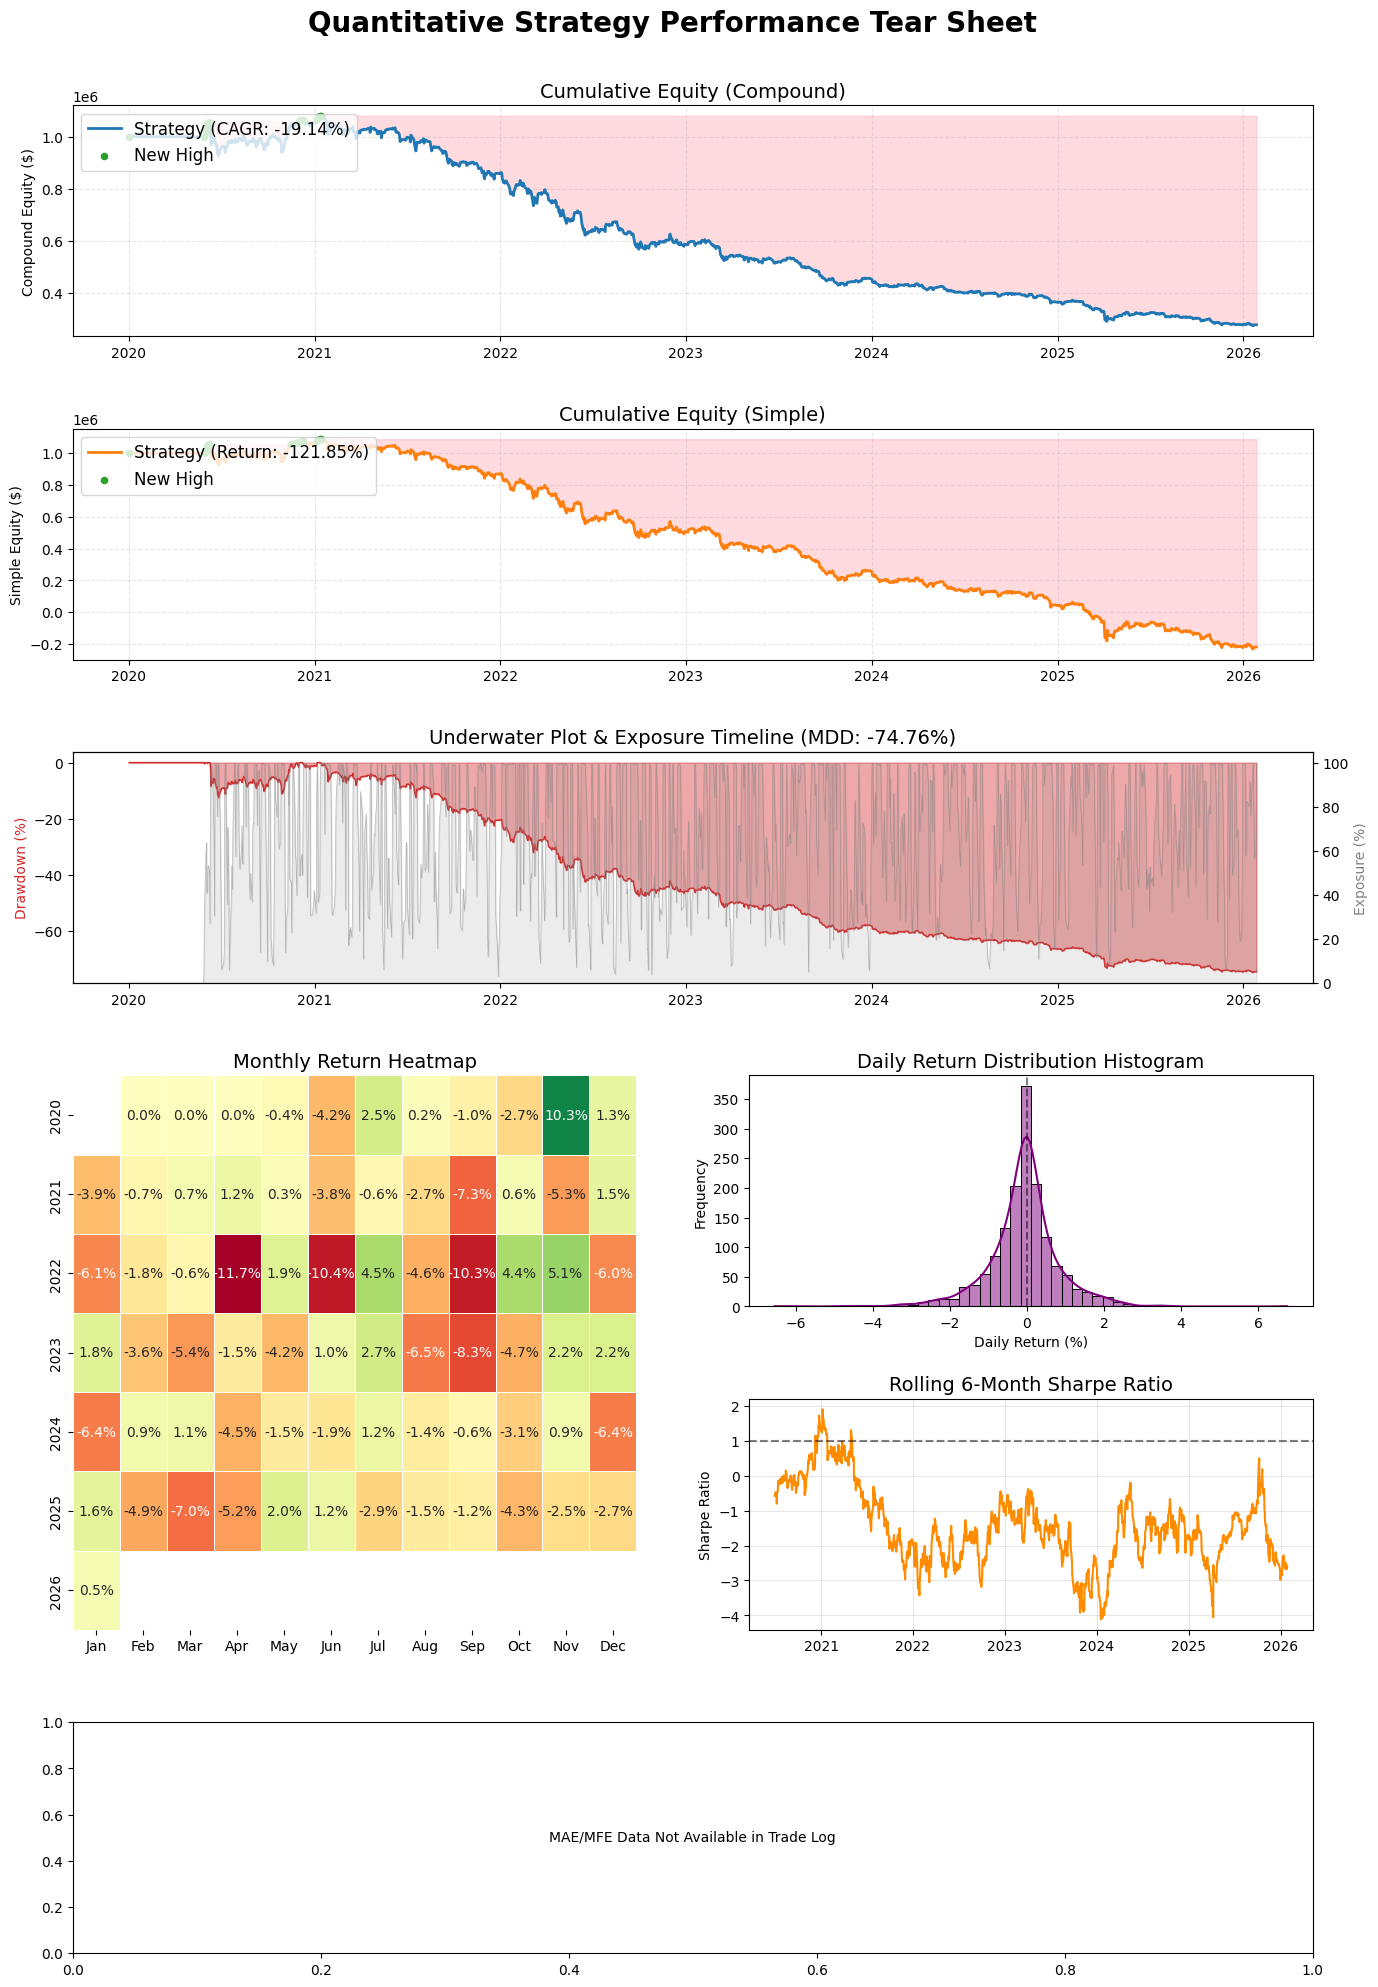

In [17]:
# ==========================================
# 4. 手動組裝大腦、財務長與保險絲 (Explicit Wiring)
# ==========================================

strategy = CRSIStrategy(test_config)
sizer = FixedRiskSizer(risk_pct=test_config['risk_pct'])

# 手動掛載保險絲 (一目了然！)
my_exits = [
    NBarExit(n=3),
    IndicatorExit(indicator='crsi', threshold=70, logic='>')
]

# ==========================================
# 5. 引擎發動！
# ==========================================
print("🚀 引擎點火，開始回測...")
engine = AdvancedEventEngine(test_config, data_feed=df)
engine.set_components(exits=my_exits, sizer=sizer, risk_stop_module=None)

daily_log, trade_log, _ = engine.run(strategy_instance=strategy)

# ==========================================
# 6. 畫出成績單
# ==========================================
print("📈 正在繪製績效報表...")
# 因為我們這次沒載入大盤 SPY，所以不傳入 benchmark_prices
analyzer = PerformanceAnalyzer(daily_log, trade_log) 
analyzer.calculate()
analyzer.plot_tearsheet()